In [1]:
%matplotlib inline

# 	线性模型实验

## 实验目的
让学生掌握对数几率回归算法的原理和实现，以及如何使用交叉验证法和留一法评估模型的泛化能力。
## 实验要求
学生需要使用Python语言编写对数几率回归算法，并在给定的数据集上进行训练和测试，比较不同验证方法的错误率，并分析结果。


## 上机内容1
阅读以下代码，结合搜索引擎，为以下代码添加注释。

**注意，请将以下代码中random_state替换为自己学号后四位。**

In [ ]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
random_state = 17

# 生成模拟的二分类数据集
X, y = make_classification(random_state=random_state)
# 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
# 创建逻辑回归模型
clf = LogisticRegression(penalty=None, )
# 训练模型
clf.fit(X_train, y_train)
# 预测测试集
y_pred = clf.predict(X_test)
# 计算准确率
print("Accuracy:", accuracy_score(y_test, y_pred))
# 输出模型参数
print("Coefficients:", clf.coef_, clf.intercept_)

Accuracy: 0.9
Coefficients: [[ 0.56840135 -0.16076032  0.20428052  0.19480881 -0.20062145  2.29379642
   0.10017235 -0.2091337  -0.31715315 -0.38865453 -0.33015591  0.3110721
   0.11028311  0.04177533 -0.21292333 -0.00509231 -0.24355608 -0.04418058
   0.28772173  0.2060628 ]] [0.15792503]


## 上机内容2
基于以下代码框架（可以适当修改），编写逻辑回归对应代码，并分析结果
1. 导入相关的库和模块，如numpy和matplotlib。
1. 写出数几率回归算法的表达式，包括线性模型、sigmoid函数、损失函数和梯度下降法。
1. 使用python和numpy实现以上线性模型、sigmoid函数、损失函数和梯度下降法。
1. 加载并预处理数据集，将特征和标签分开，将数据集划分为训练集和测试集。
1. 使用梯度下降法训练对数几率回归模型，并输出最优的参数向量。
1. 使用训练好的模型在测试集上进行预测，并计算准确率和错误率。
1. 使用0.5为阈值，画出混淆矩阵，并绘制PR曲线和ROC曲线、计算AUC值。
1. 使用10折交叉验证法和留一法分别对模型进行评估，并比较两种方法的平均错误率。

**注意，请将以下代码中random_state替换为自己学号后两位。**

训练集大小: (800, 20), 测试集大小: (200, 20)
正样本比例: 0.50

训练自定义逻辑回归模型
Iteration 0, loss: 0.554696
Iteration 1000, loss: 0.351652
Iteration 2000, loss: 0.351652
Iteration 3000, loss: 0.351652
Iteration 4000, loss: 0.351652

模型评估结果
准确率: 0.8000
错误率: 0.2000
最优参数 w: [ 0.01118702 -0.23022227  0.29659209 -0.12381138  0.18295757]... (显示前5个)
最优参数 b: -0.0542


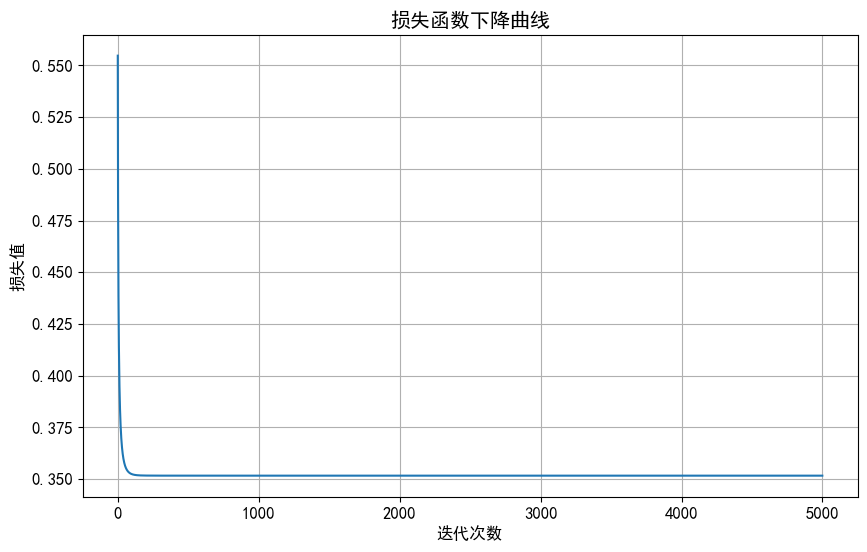

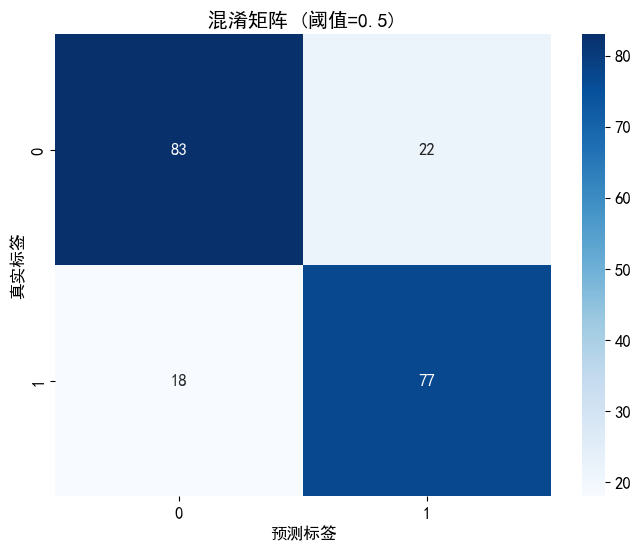


分类报告:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.78      0.81      0.79        95

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



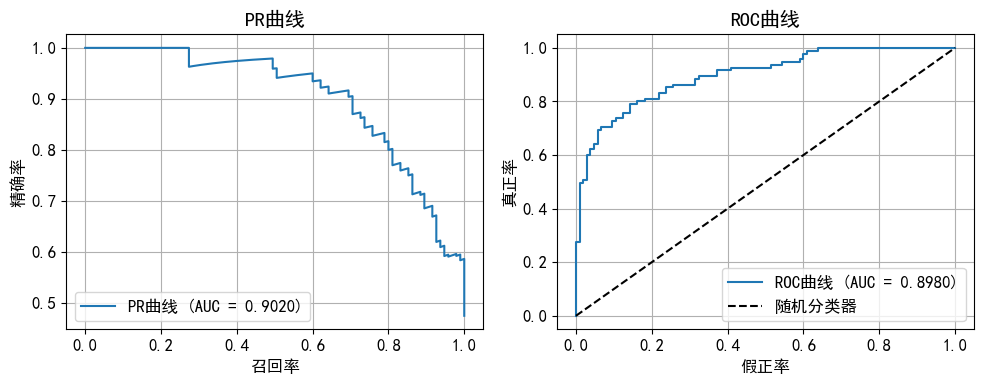

ROC AUC值: 0.8980
PR AUC值: 0.9020

交叉验证评估
Iteration 0, loss: 0.555300
Iteration 1000, loss: 0.350620
Iteration 2000, loss: 0.350620
Iteration 0, loss: 0.551300
Iteration 1000, loss: 0.361519
Iteration 2000, loss: 0.361519
Iteration 0, loss: 0.551356
Iteration 1000, loss: 0.360370
Iteration 2000, loss: 0.360370
Iteration 0, loss: 0.553788
Iteration 1000, loss: 0.354877
Iteration 2000, loss: 0.354877
Iteration 0, loss: 0.543867
Iteration 1000, loss: 0.354434
Iteration 2000, loss: 0.354434
Iteration 0, loss: 0.547469
Iteration 1000, loss: 0.367485
Iteration 2000, loss: 0.367485
Iteration 0, loss: 0.546417
Iteration 1000, loss: 0.359402
Iteration 2000, loss: 0.359402
Iteration 0, loss: 0.546670
Iteration 1000, loss: 0.360489
Iteration 2000, loss: 0.360489
Iteration 0, loss: 0.546006
Iteration 1000, loss: 0.358065
Iteration 2000, loss: 0.358065
Iteration 0, loss: 0.552343
Iteration 1000, loss: 0.367312
Iteration 2000, loss: 0.367312
10折交叉验证平均准确率: 0.8220
10折交叉验证平均错误率: 0.1780
10折交叉验证准确率标准差: 0.

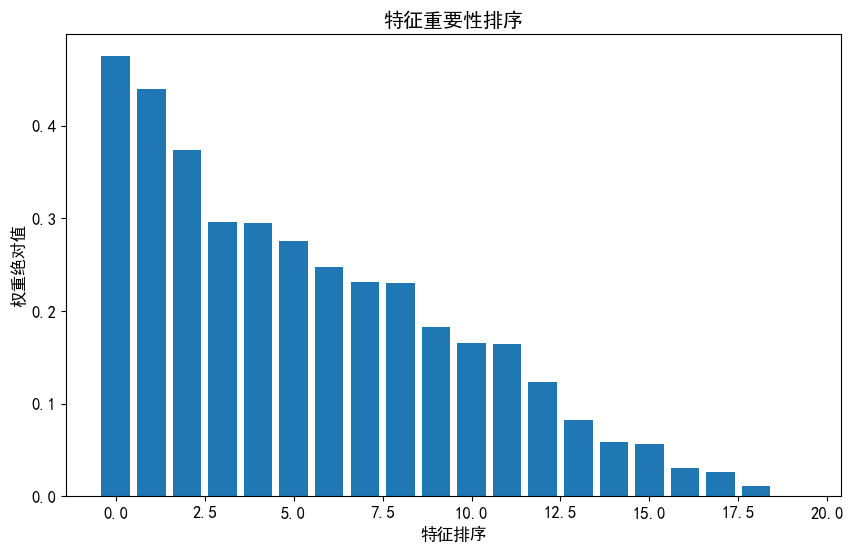

In [ ]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                           precision_recall_curve, roc_curve, auc, roc_auc_score)
import seaborn as sns
# 设置中文字体和更大的字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)
random_state = 31

# 1. 生成数据集
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                          n_redundant=5, random_state=random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"正样本比例: {np.mean(y):.2f}")

# 2. 实现逻辑回归核心函数

def linear(w, b, X):
    """线性模型: z = w^T * X + b"""
    z = np.dot(X, w) + b
    return z

def sigmoid(z):
    """Sigmoid函数: σ(z) = 1 / (1 + exp(-z))"""
    # 数值稳定性处理，防止溢出
    z = np.clip(z, -500, 500)
    y_hat = 1 / (1 + np.exp(-z))
    return y_hat

def log_likelihood_loss(y_hat, y):
    """对数似然损失函数: L = -[y*log(y_hat) + (1-y)*log(1-y_hat)]"""
    # 数值稳定性处理，防止log(0)
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

def gradient_descent(w, b, X, y, eta):
    """梯度下降法更新参数"""
    m = len(y)
    
    # 前向传播
    z = linear(w, b, X)
    y_hat = sigmoid(z)
    
    # 计算梯度
    dw = (1/m) * np.dot(X.T, (y_hat - y))
    db = (1/m) * np.sum(y_hat - y)
    
    # 更新参数
    w = w - eta * dw
    b = b - eta * db
    
    return w, b

# 3. 实现逻辑回归类
class LogisticRegression(object):
    def __init__(self, eta=0.01, iterations=10000):
        self.w = None
        self.b = None
        self.eta = eta
        self.iterations = iterations
        self.loss_history = []
        
    def fit(self, X, y):
        """训练模型"""
        # 初始化参数
        self.w = np.random.randn(X.shape[1]) * 0.01
        self.b = 0.0
        
        # 梯度下降
        for cnt in range(self.iterations):
            self.w, self.b = gradient_descent(self.w, self.b, X, y, self.eta)
            
            # 计算并记录损失
            z = linear(self.w, self.b, X)
            y_hat = sigmoid(z)
            loss = log_likelihood_loss(y_hat, y)
            self.loss_history.append(loss)
            
            if cnt % 1000 == 0:
                print(f'Iteration {cnt}, loss: {loss:.6f}')
    
    def predict_proba(self, X):
        """预测概率"""
        z = linear(self.w, self.b, X)
        return sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        y_pred_prob = self.predict_proba(X)
        return np.where(y_pred_prob > threshold, 1, 0)

# 4. 训练模型
print("\n" + "="*50)
print("训练自定义逻辑回归模型")
print("="*50)

clf = LogisticRegression(eta=0.1, iterations=5000)
clf.fit(X_train, y_train)

# 5. 在测试集上预测
y_pred = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)

print("\n" + "="*50)
print("模型评估结果")
print("="*50)

# 计算准确率和错误率
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
print(f"准确率: {accuracy:.4f}")
print(f"错误率: {error_rate:.4f}")
print(f"最优参数 w: {clf.w[:5]}... (显示前5个)") # type: ignore
print(f"最优参数 b: {clf.b:.4f}")

# 6. 绘制损失函数下降曲线
plt.figure(figsize=(10, 6))
plt.plot(clf.loss_history)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.title('损失函数下降曲线')
plt.grid(True)
plt.show()

# 7. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵 (阈值=0.5)')
plt.show()

print("\n分类报告:")
print(classification_report(y_test, y_pred))

# 8. PR曲线
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(recall, precision, label=f'PR曲线 (AUC = {pr_auc:.4f})')
plt.xlabel('召回率')
plt.ylabel('精确率')
plt.title('PR曲线')
plt.legend()
plt.grid(True)

# 9. ROC曲线
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC曲线 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='随机分类器')
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.title('ROC曲线')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC值: {roc_auc:.4f}")
print(f"PR AUC值: {pr_auc:.4f}")

# 10. 交叉验证评估
print("\n" + "="*50)
print("交叉验证评估")
print("="*50)

# 10折交叉验证
kf = KFold(n_splits=10, shuffle=True, random_state=random_state)
cv_accuracies = []
cv_errors = []

for train_idx, val_idx in kf.split(X):
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]
    
    # 训练模型
    model_cv = LogisticRegression(eta=0.1, iterations=3000)
    model_cv.fit(X_train_cv, y_train_cv)
    
    # 预测
    y_pred_cv = model_cv.predict(X_val_cv)
    acc = accuracy_score(y_val_cv, y_pred_cv)
    cv_accuracies.append(acc)
    cv_errors.append(1 - acc)

print(f"10折交叉验证平均准确率: {np.mean(cv_accuracies):.4f}")
print(f"10折交叉验证平均错误率: {np.mean(cv_errors):.4f}")
print(f"10折交叉验证准确率标准差: {np.std(cv_accuracies):.4f}")

# 留一法交叉验证（计算量较大，使用小样本演示）
print("\n留一法交叉验证（使用前100个样本演示）:")
X_small = X[:100]
y_small = y[:100]

loo = LeaveOneOut()
loo_accuracies = []
loo_errors = []
count = 0

for train_idx, val_idx in loo.split(X_small):
    X_train_loo, X_val_loo = X_small[train_idx], X_small[val_idx]
    y_train_loo, y_val_loo = y_small[train_idx], y_small[val_idx]
    
    # 训练模型
    model_loo = LogisticRegression(eta=0.1, iterations=2000)
    model_loo.fit(X_train_loo, y_train_loo)
    
    # 预测
    y_pred_loo = model_loo.predict(X_val_loo)
    acc = accuracy_score(y_val_loo, y_pred_loo)
    loo_accuracies.append(acc)
    loo_errors.append(1 - acc)
    
    count += 1
    if count % 20 == 0:
        print(f"已完成 {count}/{len(X_small)} 次留一法验证")

print(f"留一法平均准确率: {np.mean(loo_accuracies):.4f}")
print(f"留一法平均错误率: {np.mean(loo_errors):.4f}")

# 11. 与sklearn实现对比
print("\n" + "="*50)
print("与sklearn实现对比")
print("="*50)

sklearn_clf = SklearnLogisticRegression(random_state=random_state, max_iter=1000)
sklearn_clf.fit(X_train, y_train)
sklearn_pred = sklearn_clf.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_pred)

print(f"自定义模型准确率: {accuracy:.4f}")
print(f"Sklearn模型准确率: {sklearn_acc:.4f}")
print(f"准确率差异: {abs(accuracy - sklearn_acc):.4f}")

# 12. 不同阈值的影响分析
print("\n" + "="*50)
print("不同阈值对性能的影响")
print("="*50)

thresholds = np.arange(0.1, 1.0, 0.1)
for threshold in thresholds:
    y_pred_thresh = np.where(y_pred_prob > threshold, 1, 0)
    acc = accuracy_score(y_test, y_pred_thresh)
    print(f"阈值 {threshold:.1f}: 准确率 = {acc:.4f}")

# 13. 特征重要性分析
print("\n" + "="*50)
print("特征重要性分析")
print("="*50)

# 使用权重绝对值作为特征重要性指标
feature_importance = np.abs(clf.w) # type: ignore
sorted_idx = np.argsort(feature_importance)[::-1]

print("最重要的5个特征:")
for i in range(min(5, len(sorted_idx))):
    idx = sorted_idx[i]
    print(f"特征 {idx}: 权重 = {clf.w[idx]:.4f}, 重要性 = {feature_importance[idx]:.4f}")

# 绘制特征重要性
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance[sorted_idx])
plt.xlabel('特征排序')
plt.ylabel('权重绝对值')
plt.title('特征重要性排序')
plt.show()